# Walmart Store Sales — XGBoost inference

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/MLfinal/Walmart-Recruiting---Store-Sales-Forecasting/blob/dev/models/tree_based/xgboost/xgboost_inference.ipynb)

This notebook performs inference only. It downloads the `champion` raw-input XGBoost pipeline from W&B Registry, predicts directly from the unprocessed competition `test.csv`, generates a Kaggle-ready submission, and logs inference lineage and artifacts back to W&B.

No feature-engineering class definitions are repeated here. They are embedded in the registered `cloudpickle` pipeline.

In [1]:
%pip install -q "xgboost==3.3.0" "scikit-learn==1.6.1" "pandas==2.2.2" "wandb>=0.28,<1" "cloudpickle>=3.0,<4" "kaggle>=1.7,<2"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.5/75.5 kB 3.1 MB/s eta 0:00:00


In [2]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [3]:
from __future__ import annotations

import json
import os
import platform
import subprocess
import time
from pathlib import Path

import cloudpickle
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
import wandb
import xgboost as xgb

print({
    "python": platform.python_version(),
    "pandas": pd.__version__,
    "scikit_learn": sklearn.__version__,
    "xgboost": xgb.__version__,
    "cloudpickle": cloudpickle.__version__,
    "wandb": wandb.__version__,
})

{'python': '3.12.13', 'pandas': '2.2.2', 'scikit_learn': '1.6.1', 'xgboost': '3.3.0', 'cloudpickle': '3.1.2', 'wandb': '0.28.0'}


## Configuration and authentication

Store `WANDB_API_KEY` in Colab Secrets. Set `DEVICE="cpu"` only when the runtime has no CUDA GPU. Kaggle submission is disabled by default to avoid an accidental external submission.

In [4]:
DATA_DIR = Path("/content/drive/MyDrive/walmart_competition_data")
OUTPUT_DIR = Path("/content/drive/MyDrive/walmart_competition_inference/xgboost")
MODEL_DOWNLOAD_DIR = Path("/content/artifacts/wandb_registry_xgboost")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DOWNLOAD_DIR.mkdir(parents=True, exist_ok=True)

WANDB_ENTITY = "kende23-n-a"
WANDB_PROJECT = "Walmart-Recruiting---Store-Sales-Forecasting"
REGISTRY_ARTIFACT_URI = "wandb-registry-model/Walmart_XGBoost_Pipeline:champion"
PIPELINE_FILENAME = "walmart_xgboost_raw_pipeline.pkl"
DEVICE = "cuda"

SUBMIT_TO_KAGGLE = False
KAGGLE_COMPETITION = "walmart-recruiting-store-sales-forecasting"
KAGGLE_MESSAGE = "W&B champion XGBoost raw-input pipeline"

try:
    from google.colab import userdata
    wandb_api_key = userdata.get("WANDB_API_KEY")
except Exception:
    wandb_api_key = os.environ.get("WANDB_API_KEY")

wandb.login(key=wandb_api_key, relogin=False) if wandb_api_key else wandb.login()

INFERENCE_CONFIG = {
    "registry_artifact": REGISTRY_ARTIFACT_URI,
    "pipeline_filename": PIPELINE_FILENAME,
    "device": DEVICE,
    "submit_to_kaggle": SUBMIT_TO_KAGGLE,
    "competition": KAGGLE_COMPETITION,
}
INFERENCE_CONFIG

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: kende23 (kende23-n-a) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


{'registry_artifact': 'wandb-registry-model/Walmart_XGBoost_Pipeline:champion',
 'pipeline_filename': 'walmart_xgboost_raw_pipeline.pkl',
 'device': 'cuda',
 'submit_to_kaggle': False,
 'competition': 'walmart-recruiting-store-sales-forecasting'}

## Load the raw test set

Only `test.csv` is read by the inference notebook. The registered pipeline already contains store metadata, external features, fitted aggregate mappings, historical sales needed by `SalesLag52`, and the final feature order.

In [5]:
test_path = DATA_DIR / "test.csv"
assert test_path.exists(), f"Missing test file: {test_path}"

test_raw = pd.read_csv(test_path, parse_dates=["Date"])
required_columns = ["Store", "Dept", "Date", "IsHoliday"]
assert required_columns == test_raw.columns.tolist(), (
    f"Expected raw test columns {required_columns}, got {test_raw.columns.tolist()}"
)
assert not test_raw.duplicated(["Store", "Dept", "Date"]).any()
assert test_raw[required_columns].notna().all().all()

test_profile = {
    "rows": len(test_raw),
    "stores": int(test_raw["Store"].nunique()),
    "departments": int(test_raw["Dept"].nunique()),
    "weeks": int(test_raw["Date"].nunique()),
    "min_date": str(test_raw["Date"].min().date()),
    "max_date": str(test_raw["Date"].max().date()),
    "holiday_rows": int(test_raw["IsHoliday"].sum()),
}
display(pd.Series(test_profile, name="value").to_frame())
display(test_raw.head())

,value
rows,115064
stores,45
departments,81
weeks,39
min_date,2012-11-02
max_date,2013-07-26
holiday_rows,8928


,Store,Dept,Date,IsHoliday
0,1,1,2012-11-02,False
1,1,1,2012-11-09,False
2,1,1,2012-11-16,False
3,1,1,2012-11-23,True
4,1,1,2012-11-30,False


## Download the champion pipeline from W&B Registry

`use_artifact()` records the registered model version as an input to this inference run, preserving model-to-submission lineage.

In [6]:
run = wandb.init(
    entity=WANDB_ENTITY,
    project=WANDB_PROJECT,
    name=f"xgboost-inference-{pd.Timestamp.utcnow().strftime('%Y%m%d-%H%M%S')}",
    job_type="inference",
    tags=["xgboost", "inference", "registry", "champion", "kaggle-submission"],
    config={**INFERENCE_CONFIG, **test_profile},
    save_code=True,
)

model_artifact = run.use_artifact(REGISTRY_ARTIFACT_URI)
artifact_version = model_artifact.version
artifact_download_dir = MODEL_DOWNLOAD_DIR / artifact_version
downloaded_path = Path(model_artifact.download(root=str(artifact_download_dir)))

pipeline_candidates = list(downloaded_path.rglob(PIPELINE_FILENAME))
assert len(pipeline_candidates) == 1, (
    f"Expected one {PIPELINE_FILENAME}, found: {pipeline_candidates}"
)
pipeline_path = pipeline_candidates[0]

artifact_info = {
    "requested_uri": REGISTRY_ARTIFACT_URI,
    "artifact_name": model_artifact.name,
    "artifact_version": artifact_version,
    "artifact_type": model_artifact.type,
    "pipeline_path": str(pipeline_path),
}
display(pd.Series(artifact_info, name="value").to_frame())

wandb: Downloading large artifact 'Walmart_XGBoost_Pipeline:champion', 77.29MB. 6 files...
wandb:   6 of 6 files downloaded.  
Done. 00:00:02.9 (26.3MB/s)


,value
requested_uri,wandb-registry-model/Walmart_XGBoost_Pipeline:...
artifact_name,Walmart_XGBoost_Pipeline:champion
artifact_version,v1
artifact_type,model
pipeline_path,/content/artifacts/wandb_registry_xgboost/v1/w...


## Load and validate the portable pipeline

The pipeline must load without importing training-notebook classes. This is the portability contract provided by `cloudpickle`.

In [7]:
with pipeline_path.open("rb") as file:
    pipeline = cloudpickle.load(file)

assert hasattr(pipeline, "predict")
assert "feature_engineering" in pipeline.named_steps
assert "xgboost" in pipeline.named_steps

# Allow this inference runtime to choose GPU or CPU without retraining.
pipeline.named_steps["xgboost"].set_params(device=DEVICE)

feature_transformer = pipeline.named_steps["feature_engineering"]
pipeline_summary = {
    "pipeline_type": type(pipeline).__name__,
    "feature_transformer": type(feature_transformer).__name__,
    "model_type": type(pipeline.named_steps["xgboost"]).__name__,
    "engineered_features": len(feature_transformer.feature_columns_),
    "stored_history_rows": len(feature_transformer.observed_history_),
    "device": DEVICE,
}
display(pd.Series(pipeline_summary, name="value").to_frame())

,value
pipeline_type,Pipeline
feature_transformer,RawWalmartFeatureTransformer
model_type,XGBRegressor
engineered_features,81
stored_history_rows,421570
device,cuda


## Predict directly from raw test rows

In [8]:
started_at = time.perf_counter()
test_pred = pipeline.predict(test_raw)
prediction_seconds = time.perf_counter() - started_at

test_pred = np.asarray(test_pred, dtype="float64")
assert test_pred.shape == (len(test_raw),)
assert np.isfinite(test_pred).all()

prediction_stats = {
    "inference/rows": len(test_pred),
    "inference/seconds": prediction_seconds,
    "inference/rows_per_second": len(test_pred) / prediction_seconds,
    "predictions/mean": float(test_pred.mean()),
    "predictions/std": float(test_pred.std()),
    "predictions/min": float(test_pred.min()),
    "predictions/max": float(test_pred.max()),
    "predictions/negative_count": int((test_pred < 0).sum()),
}
run.log(prediction_stats)
run.summary.update(prediction_stats)
display(pd.Series(prediction_stats, name="value").to_frame())

/usr/local/lib/python3.12/dist-packages/xgboost/core.py:553: UserWarning: [20:51:57] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


,value
inference/rows,115064.000000
inference/seconds,1.109769
inference/rows_per_second,103682.850833
predictions/mean,16148.624317
predictions/std,22411.023687
predictions/min,-309.533691
predictions/max,288207.437500
predictions/negative_count,479.000000


## Prediction diagnostics

There are no test labels, so these are distribution and slicing checks—not accuracy metrics.

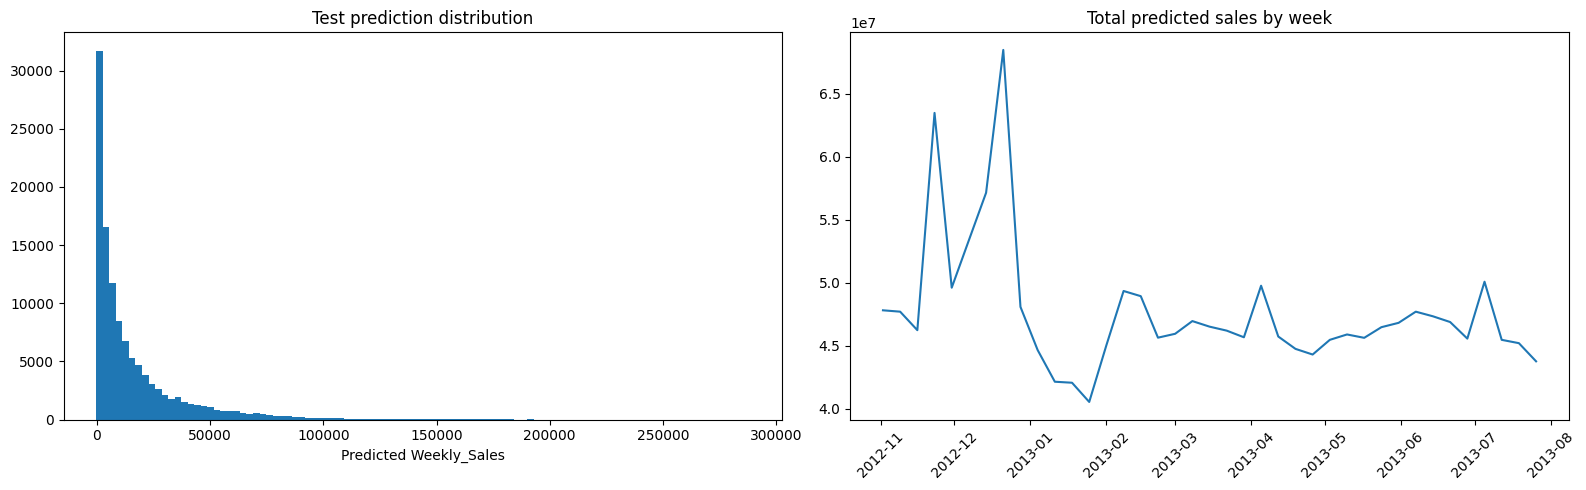

,Date,predicted_sales_sum,predicted_sales_mean,rows
0,2012-11-02,4.780509e+07,16155.825963,2959
1,2012-11-09,4.769653e+07,16054.031514,2971
2,2012-11-16,4.622608e+07,15638.051934,2956
3,2012-11-23,6.348987e+07,21333.963299,2976
4,2012-11-30,4.960124e+07,16745.859961,2962


,Store,predicted_sales_sum,predicted_sales_mean,rows
3,4,8.471646e+07,30223.497313,2803
19,20,8.268253e+07,29806.247669,2774
12,13,7.968505e+07,28097.691580,2836
1,2,7.515399e+07,26869.500273,2797
9,10,7.303170e+07,26251.510069,2782
13,14,6.984726e+07,25811.994899,2706
26,27,6.629127e+07,23751.799887,2791
0,1,6.313752e+07,22686.855372,2783
38,39,6.245998e+07,23099.104899,2704
5,6,6.198788e+07,22233.814890,2788


In [9]:
prediction_frame = test_raw.copy()
prediction_frame["Weekly_Sales"] = test_pred

weekly_summary = prediction_frame.groupby("Date").agg(
    predicted_sales_sum=("Weekly_Sales", "sum"),
    predicted_sales_mean=("Weekly_Sales", "mean"),
    rows=("Weekly_Sales", "size"),
).reset_index()
store_summary = prediction_frame.groupby("Store").agg(
    predicted_sales_sum=("Weekly_Sales", "sum"),
    predicted_sales_mean=("Weekly_Sales", "mean"),
    rows=("Weekly_Sales", "size"),
).reset_index().sort_values("predicted_sales_sum", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].hist(test_pred, bins=100)
axes[0].set_title("Test prediction distribution")
axes[0].set_xlabel("Predicted Weekly_Sales")
axes[1].plot(weekly_summary["Date"], weekly_summary["predicted_sales_sum"])
axes[1].set_title("Total predicted sales by week")
axes[1].tick_params(axis="x", rotation=45)
plt.tight_layout()

sample = prediction_frame.sample(min(5000, len(prediction_frame)), random_state=42)
run.log({
    "inference/prediction_diagnostics": wandb.Image(fig),
    "inference/weekly_summary": wandb.Table(
        dataframe=weekly_summary.assign(Date=weekly_summary["Date"].astype(str))
    ),
    "inference/store_summary": wandb.Table(dataframe=store_summary),
    "inference/prediction_sample": wandb.Table(
        dataframe=sample.assign(Date=sample["Date"].astype(str))
    ),
    "inference/prediction_histogram": wandb.Histogram(test_pred),
})
plt.show()
display(weekly_summary.head())
display(store_summary.head(10))

## Create and log the Kaggle submission

In [10]:
submission = pd.DataFrame({
    "Id": (
        test_raw["Store"].astype(str) + "_"
        + test_raw["Dept"].astype(str) + "_"
        + test_raw["Date"].dt.strftime("%Y-%m-%d")
    ),
    "Weekly_Sales": test_pred,
})

assert submission.columns.tolist() == ["Id", "Weekly_Sales"]
assert len(submission) == len(test_raw)
assert submission["Id"].is_unique
assert submission["Weekly_Sales"].notna().all()

submission_path = OUTPUT_DIR / "submission_xgboost_champion.csv"
manifest_path = OUTPUT_DIR / "submission_xgboost_champion_manifest.json"
submission.to_csv(submission_path, index=False)

manifest = {
    **artifact_info,
    **prediction_stats,
    "submission_path": str(submission_path),
    "submission_rows": len(submission),
    "created_at_utc": pd.Timestamp.utcnow().isoformat(),
    "competition": KAGGLE_COMPETITION,
}
manifest_path.write_text(json.dumps(manifest, indent=2, default=str))

submission_artifact = wandb.Artifact(
    name="walmart-xgboost-kaggle-submission",
    type="submission",
    description="Kaggle submission generated by the W&B Registry champion XGBoost pipeline.",
    metadata=manifest,
)
submission_artifact.add_file(str(submission_path))
submission_artifact.add_file(str(manifest_path))
logged_submission = run.log_artifact(
    submission_artifact,
    aliases=["latest", f"model-{artifact_version}"],
)

run.log({"submission/preview": wandb.Table(dataframe=submission.head(1000))})
run.summary["submission/path"] = str(submission_path)
run.summary["submission/model_artifact"] = f"{model_artifact.name}:{artifact_version}"

display(submission.head())
print(f"Submission saved to: {submission_path}")

,Id,Weekly_Sales
0,1_1_2012-11-02,37984.878906
1,1_1_2012-11-09,20693.759766
2,1_1_2012-11-16,19893.451172
3,1_1_2012-11-23,21634.677734
4,1_1_2012-11-30,25388.324219


Submission saved to: /content/drive/MyDrive/walmart_competition_inference/xgboost/submission_xgboost_champion.csv


## Optional Kaggle upload

Set `SUBMIT_TO_KAGGLE=True` only when you intentionally want to create a Kaggle submission. Add `KAGGLE_USERNAME` and `KAGGLE_KEY` to Colab Secrets first.

In [11]:
if SUBMIT_TO_KAGGLE:
    try:
        from google.colab import userdata
        kaggle_username = userdata.get("KAGGLE_USERNAME")
        kaggle_key = userdata.get("KAGGLE_KEY")
    except Exception:
        kaggle_username = os.environ.get("KAGGLE_USERNAME")
        kaggle_key = os.environ.get("KAGGLE_KEY")

    assert kaggle_username and kaggle_key, (
        "KAGGLE_USERNAME and KAGGLE_KEY are required in Colab Secrets."
    )
    kaggle_env = {
        **os.environ,
        "KAGGLE_USERNAME": kaggle_username,
        "KAGGLE_KEY": kaggle_key,
    }
    command = [
        "kaggle", "competitions", "submit",
        "-c", KAGGLE_COMPETITION,
        "-f", str(submission_path),
        "-m", KAGGLE_MESSAGE,
    ]
    completed = subprocess.run(
        command,
        check=True,
        capture_output=True,
        text=True,
        env=kaggle_env,
    )
    print(completed.stdout)
    run.summary["submission/kaggle_uploaded"] = True
else:
    print("Kaggle upload skipped. The submission CSV is ready for manual upload.")
    run.summary["submission/kaggle_uploaded"] = False

Kaggle upload skipped. The submission CSV is ready for manual upload.


## Finish the inference run

In [12]:
logged_submission.wait()
run.finish()
print("Inference complete: registry model → raw test → submission artifact.")

inference/rows,▁
inference/rows_per_second,▁
inference/seconds,▁
predictions/max,▁
predictions/mean,▁
predictions/min,▁
predictions/negative_count,▁
predictions/std,▁
inference/rows,115064
inference/rows_per_second,103682.85083
inference/seconds,1.10977


Inference complete: registry model → raw test → submission artifact.
